# Plant Disease Classifier
Detecting plant diseases from leaf images using CNNs.

**Goal:** Train a CNN from scratch, then fine-tune a pretrained model to beat it — with honest evaluation and failure analysis.

**Author:** Syeda Aliza Ayaz

---

## Phase 1 — Setup & GPU Check
Confirming PyTorch is installed and the GPU is available.

In [15]:
import torch

# Check if PyTorch can see the GPU
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU — go to Runtime > Change runtime type > T4 GPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


## Phase 2 — Get the Data (via Kaggle)
Authenticating with Kaggle using credentials stored in Colab Secrets (kept private), then downloading a PlantVillage dataset.

In [16]:
# Pull Kaggle credentials from Colab Secrets and set them as environment
# variables, which is what the kaggle tool reads. Nothing secret is printed.
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Install the kaggle command-line tool (quietly)
!pip install -q kaggle

print("Kaggle credentials loaded. Testing connection...")
# List a couple of datasets just to confirm auth works
!kaggle datasets list -s plantvillage --max-size 5 | head -n 5

Kaggle credentials loaded. Testing connection...
ref                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
devharis/plantvillage-yolo-modified  PlantVillage Object Detection YOLO Dataset (Modifi   861229997  2026-02-24 09:28:49.077000             40          2  0.5625           
ouissamtamimi/plantvillage           plantvillage                                         117758648  2026-06-17 17:11:47.470000              1          0  0.125            


### Downloading the dataset
Pulling a clean, classification-ready PlantVillage dataset (leaf images sorted into folders by disease), then unzipping it.

In [17]:
# Download a clean, classification-style PlantVillage dataset.
# This one is organised as folders-per-disease, which is exactly what we need.
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

print("\nDownload done. Now unzipping...")

import zipfile
with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plantvillage_data')

print("Unzipped into the 'plantvillage_data' folder.")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

Download done. Now unzipping...
Unzipped into the 'plantvillage_data' folder.


## Phase 3 — Explore the Data
Before training anything, we look at how the dataset is organised, how many classes and images there are, and view a few real leaf images. Never trust a dataset you haven't inspected.

In [18]:
import os

# The unzip created a folder; let's see how it's structured inside.
# We'll walk the top levels to understand the layout.
base = 'plantvillage_data'

for root, dirs, files in os.walk(base):
    # Only show the first couple of levels to avoid a huge printout
    depth = root.replace(base, '').count(os.sep)
    if depth < 4:
        print(f"{'  ' * depth}{os.path.basename(root)}/  ({len(dirs)} folders, {len(files)} files)")

plantvillage_data/  (1 folders, 0 files)
  plantvillage dataset/  (3 folders, 0 files)
    grayscale/  (38 folders, 0 files)
      Strawberry___healthy/  (0 folders, 456 files)
      Tomato___Tomato_Yellow_Leaf_Curl_Virus/  (0 folders, 5357 files)
      Corn_(maize)___Northern_Leaf_Blight/  (0 folders, 985 files)
      Potato___healthy/  (0 folders, 152 files)
      Grape___healthy/  (0 folders, 423 files)
      Tomato___Target_Spot/  (0 folders, 1404 files)
      Peach___healthy/  (0 folders, 360 files)
      Raspberry___healthy/  (0 folders, 371 files)
      Potato___Early_blight/  (0 folders, 1000 files)
      Apple___Apple_scab/  (0 folders, 630 files)
      Corn_(maize)___healthy/  (0 folders, 1162 files)
      Squash___Powdery_mildew/  (0 folders, 1835 files)
      Apple___Cedar_apple_rust/  (0 folders, 275 files)
      Tomato___healthy/  (0 folders, 1591 files)
      Apple___healthy/  (0 folders, 1645 files)
      Apple___Black_rot/  (0 folders, 621 files)
      Blueberry___heal

### Selecting a subset — 10 balanced classes across 4 plants
We use 10 classes (all with 1000+ images) spanning tomato, corn, grape, and potato. Mixing plants forces the model to learn both plant type and disease. We deliberately include confusable disease pairs (early vs. late blight in tomato and potato) so the failure analysis has a meaningful story. Capped at ~600 images/class for fast training on free Colab.

In [19]:
import os

data_root = 'plantvillage_data/plantvillage dataset/color'

# 10 balanced classes across 4 plants, with confusable pairs built in
selected_classes = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Bacterial_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Potato___Early_blight',
    'Potato___Late_blight',
]

# Cap per class to keep training fast on free Colab
IMAGES_PER_CLASS = 600

# Verify each folder exists and count images
print("Checking selected classes:\n")
all_good = True
for cls in selected_classes:
    folder = os.path.join(data_root, cls)
    if os.path.isdir(folder):
        n = len(os.listdir(folder))
        print(f"  ✓ {cls}: {n} images (will use {min(n, IMAGES_PER_CLASS)})")
    else:
        print(f"  ✗ NOT FOUND: {folder}")
        all_good = False

print(f"\nTotal classes: {len(selected_classes)}")
print(f"Approx total images: {len(selected_classes) * IMAGES_PER_CLASS}")
if all_good:
    print("All classes found — ready for the next step.")
else:
    print("⚠️ Some classes missing — check the paths above before continuing.")

Checking selected classes:

  ✓ Tomato___healthy: 1591 images (will use 600)
  ✓ Tomato___Early_blight: 1000 images (will use 600)
  ✓ Tomato___Late_blight: 1909 images (will use 600)
  ✓ Tomato___Bacterial_spot: 2127 images (will use 600)
  ✓ Corn_(maize)___Common_rust_: 1192 images (will use 600)
  ✓ Corn_(maize)___healthy: 1162 images (will use 600)
  ✓ Grape___Black_rot: 1180 images (will use 600)
  ✓ Grape___Esca_(Black_Measles): 1383 images (will use 600)
  ✓ Potato___Early_blight: 1000 images (will use 600)
  ✓ Potato___Late_blight: 1000 images (will use 600)

Total classes: 10
Approx total images: 6000
All classes found — ready for the next step.


### Viewing sample images
Displaying a few real leaves from each class. We want to see what "healthy" vs. each disease actually looks like, and confirm the images are what we expect before building the training pipeline.

Tomato___healthy: image size = (256, 256)
Tomato___Early_blight: image size = (256, 256)
Tomato___Late_blight: image size = (256, 256)
Tomato___Bacterial_spot: image size = (256, 256)


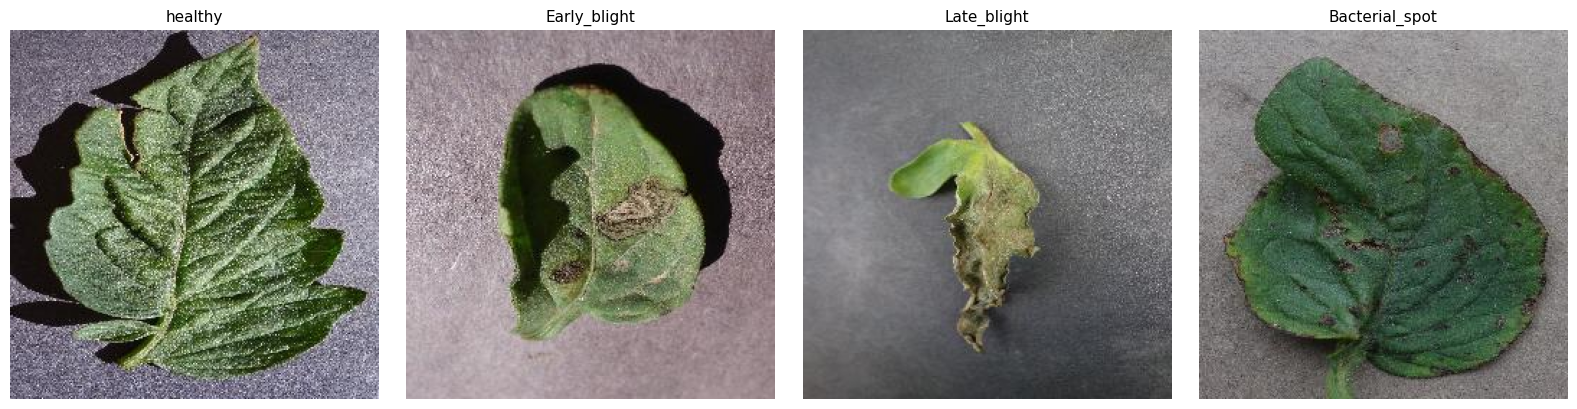

In [20]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# We'll show 4 sample images — one from each class — in a row.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, cls in zip(axes, selected_classes):
    folder = os.path.join(data_root, cls)
    # Grab the first image file in the folder
    first_image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, first_image_name)

    # Open the image and show it
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(cls.replace('Tomato___', ''), fontsize=11)
    ax.axis('off')  # hide the x/y number axes — we just want the picture

    # Print the image size once, so we know the dimensions we're dealing with
    print(f"{cls}: image size = {img.size}")

plt.tight_layout()
plt.show()

## Phase 4 — Prepare the Data (Transforms + Train/Val/Test Split)
Neural networks eat tensors (grids of numbers), not image files. Here we:
1. Define **transforms**: resize images to 128×128, convert to tensors, normalize pixel values.
2. Build the dataset from our 10 classes (capped at 600 images each).
3. Split into **train / validation / test** — the single most important habit for honest results.

In [21]:
import os
import random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

random.seed(42)  # makes the split reproducible — same shuffle every run

# --- 1. Define the transforms ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),          # all images to 128x128
    transforms.ToTensor(),                   # image -> tensor, pixels scaled to [0,1]
    transforms.Normalize(                    # center values around 0
        mean=[0.485, 0.456, 0.406],          # standard ImageNet means (R,G,B)
        std=[0.229, 0.224, 0.225]            # standard ImageNet stds
    )
])

# --- 2. Build a list of (image_path, label) pairs, capped at 600 per class ---
data_root = 'plantvillage_data/plantvillage dataset/color'
IMAGES_PER_CLASS = 600

samples = []  # each entry: (full_image_path, class_index)
for class_index, cls in enumerate(selected_classes):
    folder = os.path.join(data_root, cls)
    files = os.listdir(folder)
    random.shuffle(files)                    # shuffle so we take a random 600, not the first 600
    files = files[:IMAGES_PER_CLASS]         # cap
    for fname in files:
        samples.append((os.path.join(folder, fname), class_index))

random.shuffle(samples)  # shuffle the whole list so classes are mixed

# --- 3. Split into train / val / test (70 / 15 / 15) ---
n_total = len(samples)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_samples = samples[:n_train]
val_samples   = samples[n_train:n_train + n_val]
test_samples  = samples[n_train + n_val:]

print(f"Total images:      {n_total}")
print(f"Training set:      {len(train_samples)}")
print(f"Validation set:    {len(val_samples)}")
print(f"Test set:          {len(test_samples)}")

Total images:      6000
Training set:      4200
Validation set:    900
Test set:          900


### Dataset & DataLoaders
Our split is just lists of file paths right now. Here we wrap them in a PyTorch **Dataset** (which loads and transforms one image on demand) and **DataLoaders** (which serve images in batches during training). Loading on demand keeps memory low — we never hold all 6000 images at once.

In [22]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# --- A custom Dataset: knows how to load ONE image + its label ---
class LeafDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples        # list of (path, label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)      # how many images total

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')   # load image, force 3 channels
        image = self.transform(image)             # apply resize/tensor/normalize
        return image, label

# --- Build the three datasets ---
train_dataset = LeafDataset(train_samples, transform)
val_dataset   = LeafDataset(val_samples, transform)
test_dataset  = LeafDataset(test_samples, transform)

# --- DataLoaders: serve images in batches ---
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per epoch — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

# --- Sanity check: grab one batch and inspect its shape ---
images, labels = next(iter(train_loader))
print(f"One batch of images: {images.shape}")   # expect [32, 3, 128, 128]
print(f"One batch of labels: {labels.shape}")    # expect [32]
print(f"Label values in this batch: {labels[:8].tolist()} ...")

Batches per epoch — train: 132, val: 29, test: 29
One batch of images: torch.Size([32, 3, 128, 128])
One batch of labels: torch.Size([32])
Label values in this batch: [0, 2, 8, 8, 0, 0, 8, 2] ...


## Phase 5 — Build a CNN From Scratch
We define our own convolutional neural network, layer by layer. A CNN learns visual patterns in stages: early layers detect simple things (edges, colors), deeper layers combine them into complex patterns (leaf textures, disease spots). We build it ourselves (rather than downloading a pretrained one) to understand the mechanics — and later we'll compare it against a fine-tuned pretrained model.

In [23]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # --- Convolutional feature extractor ---
        # Conv layer args: (input_channels, output_channels, kernel_size, padding)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)    # 3 (RGB) -> 16 feature maps
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)   # 16 -> 32
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)   # 32 -> 64

        self.pool = nn.MaxPool2d(2, 2)   # halves height & width each time

        # --- Classifier head ---
        # After 3 pools, a 128x128 image becomes 16x16 (128 -> 64 -> 32 -> 16)
        # with 64 channels, so flattened size = 64 * 16 * 16
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.5)   # randomly drops half the neurons during training (fights overfitting)

    def forward(self, x):
        # x starts as [batch, 3, 128, 128]
        x = self.pool(F.relu(self.conv1(x)))   # -> [batch, 16, 64, 64]
        x = self.pool(F.relu(self.conv2(x)))   # -> [batch, 32, 32, 32]
        x = self.pool(F.relu(self.conv3(x)))   # -> [batch, 64, 16, 16]

        x = x.view(x.size(0), -1)              # flatten to [batch, 64*16*16]
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # -> [batch, 10] (one score per class)
        return x

# Create the model and move it to the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN(num_classes=10).to(device)

print(model)
print(f"\nModel is on: {device}")

# Count trainable parameters (a sense of model size)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Model is on: cuda
Total trainable parameters: 2,122,154


## Phase 6 — Train the CNN
Training = showing the model batches of images, letting it guess, measuring how wrong it is (the "loss"), and nudging its parameters to be slightly less wrong each time. We track training AND validation performance every epoch so we can see if the model is genuinely learning or just memorizing (overfitting).

In [24]:
import torch.optim as optim
import time

# --- Loss function and optimizer ---
criterion = nn.CrossEntropyLoss()                    # measures how wrong predictions are
optimizer = optim.Adam(model.parameters(), lr=0.001) # updates the model's weights

# --- A helper to measure accuracy on any loader (no training) ---
def evaluate(loader):
    model.eval()                    # eval mode (turns off dropout)
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():           # don't compute gradients — faster, we're only measuring
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item()
            preds = outputs.argmax(1)             # predicted class = highest score
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / len(loader), correct / total

# --- Training loop ---
EPOCHS = 12
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting training...\n")
for epoch in range(EPOCHS):
    model.train()                   # training mode (dropout active)
    running_loss, correct, total = 0.0, 0, 0
    start = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()       # reset gradients from last step
        outputs = model(images)     # forward pass
        loss = criterion(outputs, labels)  # how wrong?
        loss.backward()             # backward pass (compute gradients)
        optimizer.step()            # update weights

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate(val_loader)   # check on unseen data

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.3f} acc {val_acc:.3f} | "
          f"{time.time()-start:.0f}s")

print("\nTraining done!")

Starting training...

Epoch  1/12 | train loss 1.207 acc 0.564 | val loss 0.659 acc 0.744 | 24s
Epoch  2/12 | train loss 0.595 acc 0.782 | val loss 0.424 acc 0.834 | 13s
Epoch  3/12 | train loss 0.462 acc 0.829 | val loss 0.338 acc 0.877 | 11s
Epoch  4/12 | train loss 0.363 acc 0.870 | val loss 0.330 acc 0.896 | 12s
Epoch  5/12 | train loss 0.303 acc 0.891 | val loss 0.301 acc 0.898 | 11s
Epoch  6/12 | train loss 0.268 acc 0.903 | val loss 0.288 acc 0.898 | 12s
Epoch  7/12 | train loss 0.214 acc 0.923 | val loss 0.343 acc 0.871 | 11s
Epoch  8/12 | train loss 0.209 acc 0.928 | val loss 0.324 acc 0.887 | 11s
Epoch  9/12 | train loss 0.152 acc 0.947 | val loss 0.310 acc 0.901 | 11s
Epoch 10/12 | train loss 0.134 acc 0.951 | val loss 0.346 acc 0.903 | 11s
Epoch 11/12 | train loss 0.126 acc 0.957 | val loss 0.252 acc 0.924 | 12s
Epoch 12/12 | train loss 0.099 acc 0.965 | val loss 0.321 acc 0.922 | 11s

Training done!


### Saving the trained model
Training is fast here (~3 min), but we save the trained weights so we don't have to retrain every session. We mount Google Drive and save there so it persists even if the Colab session resets.

In [29]:
# run only when u have already mounted
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [33]:
from google.colab import drive
# uncomment this line if u are running the project for the first time
# drive.mount('/content/drive', force_remount=True)

import os
save_dir = '/content/drive/MyDrive/Plant_Disease_Diagnosis/leaf_project'
os.makedirs(save_dir, exist_ok=True)

# Save the model's learned weights + the training history
torch.save(model.state_dict(), f'{save_dir}/scratch_cnn.pth')

import json
with open(f'{save_dir}/scratch_cnn_history.json', 'w') as f:
    json.dump(history, f)

print(f"Model saved to {save_dir}/scratch_cnn.pth")
print("History saved too — we can plot learning curves anytime.")

print("Files in save_dir:", os.listdir(save_dir))

Model saved to /content/drive/MyDrive/Plant_Disease_Diagnosis/leaf_project/scratch_cnn.pth
History saved too — we can plot learning curves anytime.
Files in save_dir: ['scratch_cnn.pth', 'scratch_cnn_history.json']


## Phase 7 — Honest Evaluation
Numbers in a training log aren't enough. Here we:
1. **Plot learning curves** — visualize the overfitting we spotted (train vs. val).
2. **Build a confusion matrix** on the untouched TEST set — see exactly which diseases the model confuses.
3. **Report per-class precision/recall/F1** — so we know its strengths and weaknesses class-by-class.
This is the evaluation rigor that separates a real project from a demo.

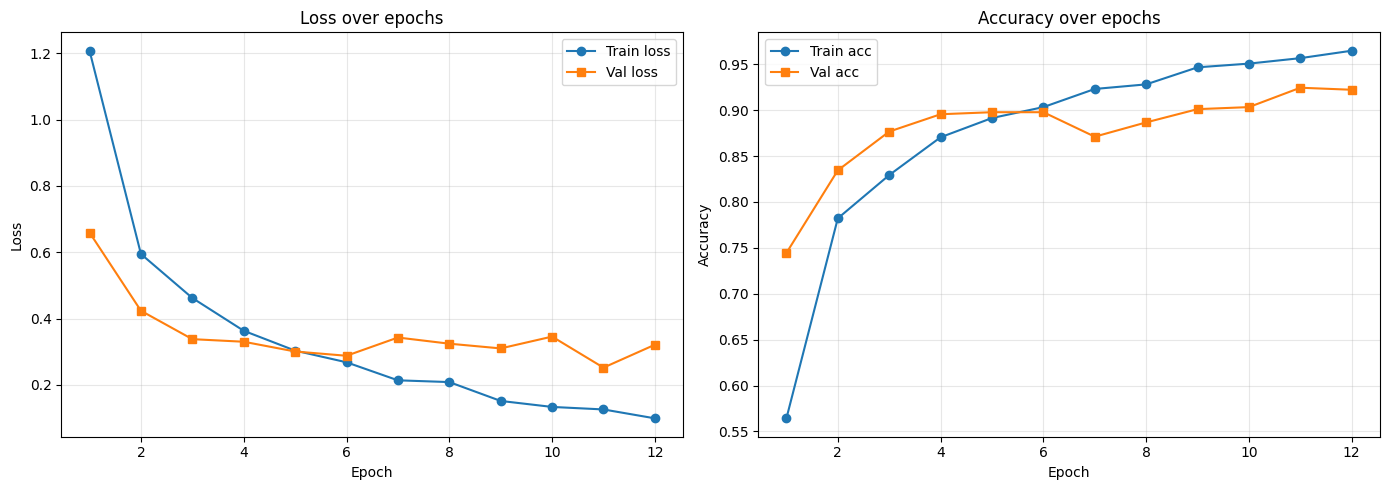

TEST accuracy (untouched data): 0.910



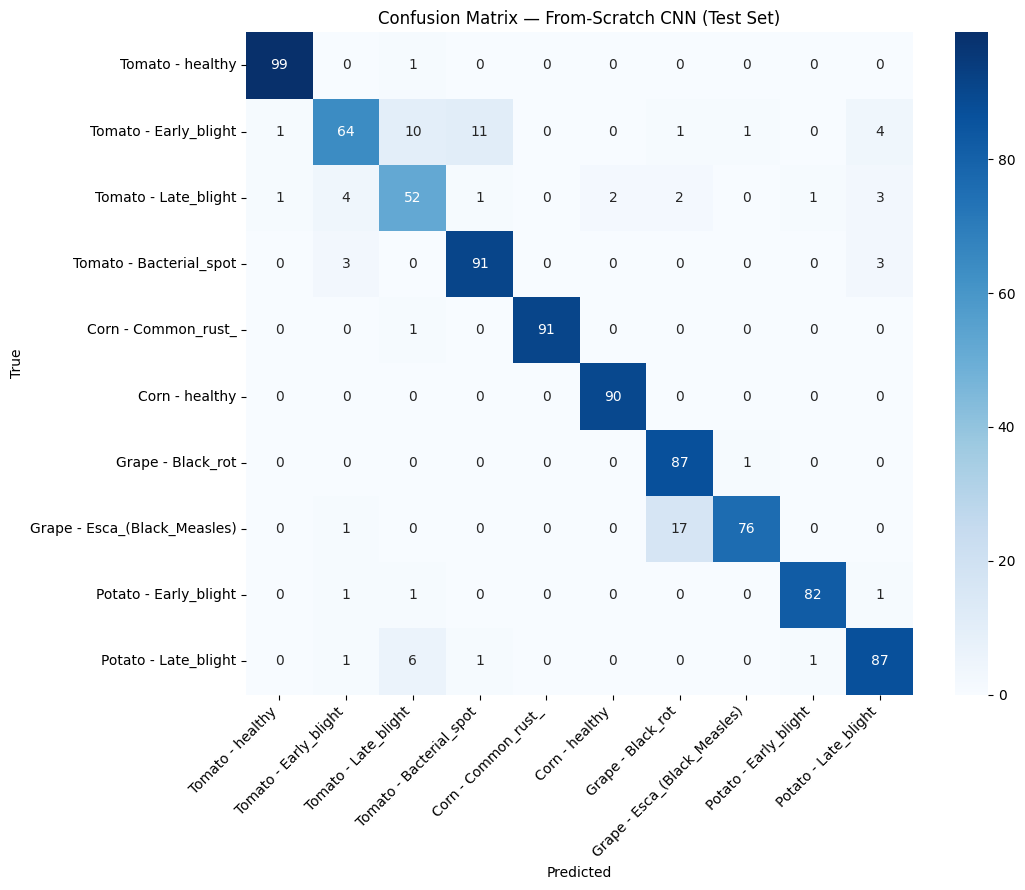

Per-class precision / recall / F1:

                              precision    recall  f1-score   support

            Tomato - healthy      0.980     0.990     0.985       100
       Tomato - Early_blight      0.865     0.696     0.771        92
        Tomato - Late_blight      0.732     0.788     0.759        66
     Tomato - Bacterial_spot      0.875     0.938     0.905        97
         Corn - Common_rust_      1.000     0.989     0.995        92
              Corn - healthy      0.978     1.000     0.989        90
           Grape - Black_rot      0.813     0.989     0.892        88
Grape - Esca_(Black_Measles)      0.974     0.809     0.884        94
       Potato - Early_blight      0.976     0.965     0.970        85
        Potato - Late_blight      0.888     0.906     0.897        96

                    accuracy                          0.910       900
                   macro avg      0.908     0.907     0.905       900
                weighted avg      0.914     0.910   

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ============ 1. LEARNING CURVES ============
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train loss')
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss over epochs')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train acc')
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy over epochs')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 2. PREDICTIONS ON THE TEST SET ============
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"TEST accuracy (untouched data): {test_acc:.3f}\n")

# ============ 3. CONFUSION MATRIX ============
# Short labels for readability
short_names = [c.replace('_(maize)', '').replace('___', ' - ') for c in selected_classes]

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — From-Scratch CNN (Test Set)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/fig_cm_scratch.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ 4. PER-CLASS METRICS ============
print("Per-class precision / recall / F1:\n")
print(classification_report(all_labels, all_preds, target_names=short_names, digits=3))

In [48]:
# os.listdir(f'{save_dir}')
os.listdir('/content/drive/MyDrive/')

['leaf_project', 'Plant_Disease_Diagnosis']

## Phase 8 — Transfer Learning: Fine-Tune a Pretrained Model
Our from-scratch CNN hit 89.8% but struggles with visually-similar disease pairs. Now we fine-tune a ResNet-18 (pretrained on ImageNet's millions of images) on our leaf data. The research question: does transfer learning improve overall accuracy, and does it fix the blight confusion — or struggle there too?

In [35]:
from torchvision import models

# --- Load ResNet-18 pretrained on ImageNet ---
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# --- Replace the final layer to output OUR 10 classes ---
# ResNet's original final layer outputs 1000 (ImageNet classes); we swap it for 10.
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

resnet = resnet.to(device)

# --- Same loss; optimizer now targets ResNet's parameters ---
criterion = nn.CrossEntropyLoss()
optimizer_rn = optim.Adam(resnet.parameters(), lr=0.0001)  # smaller LR for fine-tuning

# --- Train (reusing the same loop structure) ---
EPOCHS = 8   # pretrained models converge faster, so fewer epochs
history_rn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def evaluate_model(m, loader):
    m.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = m(images)
            loss_sum += criterion(outputs, labels).item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return loss_sum / len(loader), correct / total

print("Fine-tuning ResNet-18...\n")
for epoch in range(EPOCHS):
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0
    start = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_rn.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_rn.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    val_loss, val_acc = evaluate_model(resnet, val_loader)
    for k, v in zip(history_rn, [train_loss, val_loss, train_acc, val_acc]):
        history_rn[k].append(v)
    print(f"Epoch {epoch+1}/{EPOCHS} | train loss {train_loss:.3f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.3f} acc {val_acc:.3f} | {time.time()-start:.0f}s")

print("\nDone!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


Fine-tuning ResNet-18...

Epoch 1/8 | train loss 0.347 acc 0.896 | val loss 0.106 acc 0.959 | 15s
Epoch 2/8 | train loss 0.032 acc 0.994 | val loss 0.081 acc 0.974 | 14s
Epoch 3/8 | train loss 0.019 acc 0.997 | val loss 0.083 acc 0.973 | 14s
Epoch 4/8 | train loss 0.020 acc 0.995 | val loss 0.086 acc 0.967 | 14s
Epoch 5/8 | train loss 0.021 acc 0.995 | val loss 0.066 acc 0.972 | 14s
Epoch 6/8 | train loss 0.008 acc 0.998 | val loss 0.079 acc 0.973 | 14s
Epoch 7/8 | train loss 0.026 acc 0.993 | val loss 0.088 acc 0.973 | 14s
Epoch 8/8 | train loss 0.017 acc 0.995 | val loss 0.054 acc 0.979 | 14s

Done!


### Evaluate ResNet on the test set + save
Same honest evaluation as before — confusion matrix and per-class metrics on the untouched test set — so we can compare ResNet directly against the from-scratch CNN. The key question: are the tomato/potato blight confusions reduced?

ResNet saved to Drive.

ResNet-18 TEST accuracy: 0.978
From-scratch CNN TEST accuracy: 0.910
Improvement: +6.8 percentage points



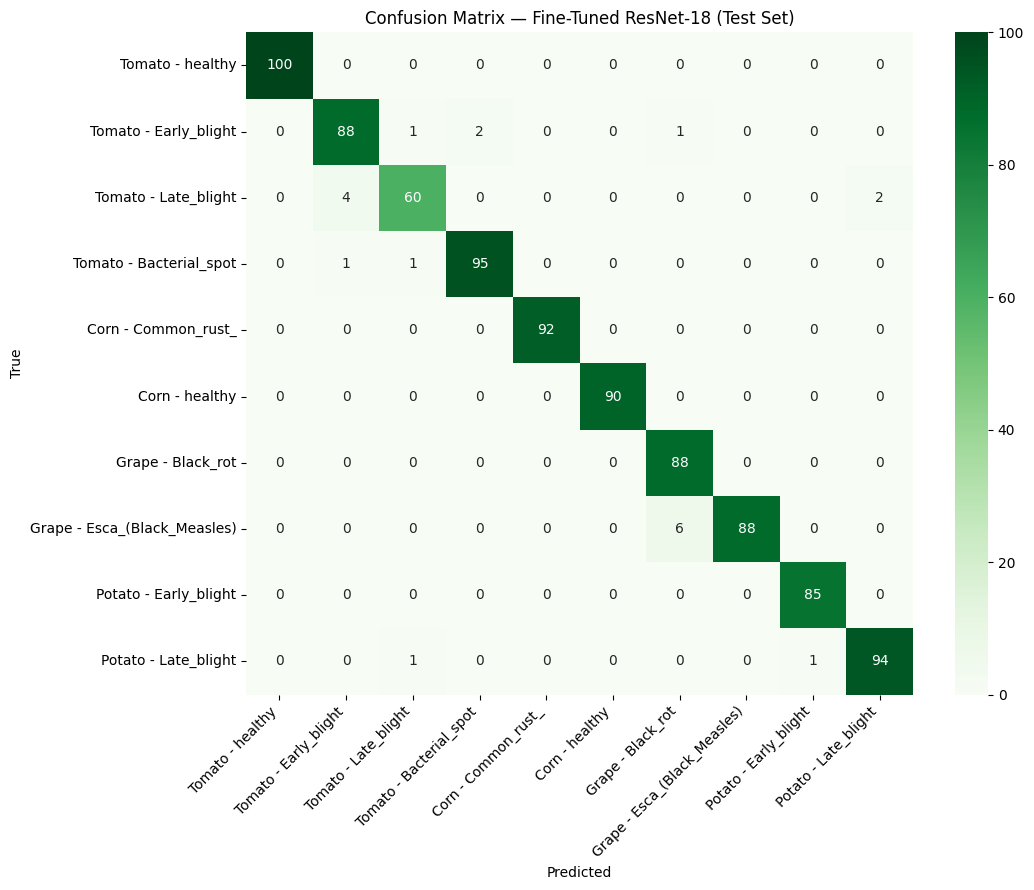

ResNet-18 per-class precision / recall / F1:

                              precision    recall  f1-score   support

            Tomato - healthy      1.000     1.000     1.000       100
       Tomato - Early_blight      0.946     0.957     0.951        92
        Tomato - Late_blight      0.952     0.909     0.930        66
     Tomato - Bacterial_spot      0.979     0.979     0.979        97
         Corn - Common_rust_      1.000     1.000     1.000        92
              Corn - healthy      1.000     1.000     1.000        90
           Grape - Black_rot      0.926     1.000     0.962        88
Grape - Esca_(Black_Measles)      1.000     0.936     0.967        94
       Potato - Early_blight      0.988     1.000     0.994        85
        Potato - Late_blight      0.979     0.979     0.979        96

                    accuracy                          0.978       900
                   macro avg      0.977     0.976     0.976       900
                weighted avg      0.978   

In [52]:
# --- Save the fine-tuned model first ---
torch.save(resnet.state_dict(), f'{save_dir}/resnet18_finetuned.pth')
with open(f'{save_dir}/resnet18_history.json', 'w') as f:
    json.dump(history_rn, f)
print("ResNet saved to Drive.\n")

# --- Predictions on the test set ---
resnet.eval()
rn_preds, rn_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet(images)
        rn_preds.extend(outputs.argmax(1).cpu().numpy())
        rn_labels.extend(labels.numpy())

rn_preds = np.array(rn_preds)
rn_labels = np.array(rn_labels)

rn_test_acc = (rn_preds == rn_labels).mean()
print(f"ResNet-18 TEST accuracy: {rn_test_acc:.3f}")
print(f"From-scratch CNN TEST accuracy: {test_acc:.3f}")
print(f"Improvement: +{(rn_test_acc - test_acc)*100:.1f} percentage points\n")

# --- Confusion matrix for ResNet ---
cm_rn = confusion_matrix(rn_labels, rn_preds)
plt.figure(figsize=(11, 9))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Fine-Tuned ResNet-18 (Test Set)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/fig_cm_resnet.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Per-class metrics ---
print("ResNet-18 per-class precision / recall / F1:\n")
print(classification_report(rn_labels, rn_preds, target_names=short_names, digits=3))

## Phase 9 — Ablation: Does Data Augmentation Help?
We retrain the SAME from-scratch CNN, but now with data augmentation (random flips, rotations, brightness/color shifts) on the training images. This tests whether augmentation (a) improves overall accuracy and (b) reduces the stubborn tomato early-vs-late blight confusion — which tells us if that confusion is fixable or genuinely intrinsic.

In [37]:
# --- Augmented transform for TRAINING only ---
# Note: val/test keep the original (non-augmented) transform — we only augment training.
train_transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),                    # random left-right flip
    transforms.RandomRotation(20),                        # random rotation up to 20°
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # random brightness/contrast shifts
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- New training dataset/loader WITH augmentation (val/test unchanged) ---
train_dataset_aug = LeafDataset(train_samples, train_transform_aug)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)

# --- Fresh from-scratch model (same architecture, retrained from zero) ---
model_aug = SimpleCNN(num_classes=10).to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

EPOCHS = 12
history_aug = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Training from-scratch CNN WITH augmentation...\n")
for epoch in range(EPOCHS):
    model_aug.train()
    running_loss, correct, total = 0.0, 0, 0
    start = time.time()
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        outputs = model_aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / len(train_loader_aug)
    train_acc = correct / total
    val_loss, val_acc = evaluate_model(model_aug, val_loader)
    for k, v in zip(history_aug, [train_loss, val_loss, train_acc, val_acc]):
        history_aug[k].append(v)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | train loss {train_loss:.3f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.3f} acc {val_acc:.3f} | {time.time()-start:.0f}s")

# --- Evaluate on test set ---
model_aug.eval()
aug_preds, aug_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        aug_preds.extend(model_aug(images).argmax(1).cpu().numpy())
        aug_labels.extend(labels.numpy())
aug_preds, aug_labels = np.array(aug_preds), np.array(aug_labels)
aug_test_acc = (aug_preds == aug_labels).mean()

print(f"\n=== ABLATION RESULTS (test set) ===")
print(f"From-scratch, NO augmentation:  {test_acc:.3f}")
print(f"From-scratch, WITH augmentation: {aug_test_acc:.3f}")
print(f"ResNet-18 (transfer learning):   {rn_test_acc:.3f}")

# Save
torch.save(model_aug.state_dict(), f'{save_dir}/scratch_cnn_augmented.pth')
with open(f'{save_dir}/scratch_cnn_aug_history.json', 'w') as f:
    json.dump(history_aug, f)
print("\nAugmented model saved.")

Training from-scratch CNN WITH augmentation...

Epoch  1/12 | train loss 1.385 acc 0.512 | val loss 0.727 acc 0.748 | 25s
Epoch  2/12 | train loss 0.805 acc 0.713 | val loss 0.486 acc 0.819 | 17s
Epoch  3/12 | train loss 0.634 acc 0.774 | val loss 0.382 acc 0.868 | 14s
Epoch  4/12 | train loss 0.552 acc 0.804 | val loss 0.324 acc 0.899 | 14s
Epoch  5/12 | train loss 0.487 acc 0.828 | val loss 0.331 acc 0.882 | 14s
Epoch  6/12 | train loss 0.437 acc 0.842 | val loss 0.298 acc 0.901 | 15s
Epoch  7/12 | train loss 0.401 acc 0.854 | val loss 0.292 acc 0.901 | 15s
Epoch  8/12 | train loss 0.390 acc 0.862 | val loss 0.274 acc 0.913 | 15s
Epoch  9/12 | train loss 0.355 acc 0.877 | val loss 0.236 acc 0.914 | 15s
Epoch 10/12 | train loss 0.324 acc 0.880 | val loss 0.221 acc 0.921 | 15s
Epoch 11/12 | train loss 0.287 acc 0.899 | val loss 0.192 acc 0.932 | 15s
Epoch 12/12 | train loss 0.281 acc 0.901 | val loss 0.213 acc 0.918 | 17s

=== ABLATION RESULTS (test set) ===
From-scratch, NO augmentati

### Augmented model — confusion matrix & the blight question
The decisive test: does augmentation reduce the tomato early-vs-late blight confusion, or does it persist even here? If it persists across all three models, that strongly supports the confusion being intrinsic to the diseases rather than a model artifact.

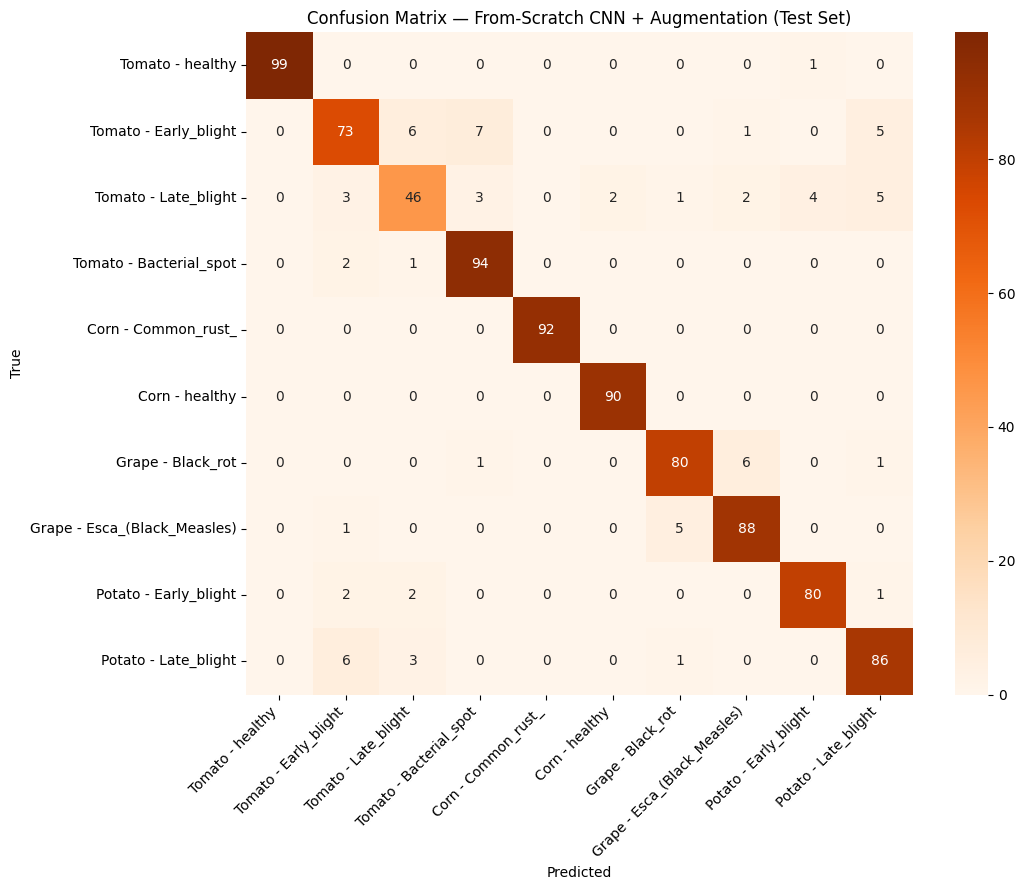

Augmented from-scratch — per-class metrics:

                              precision    recall  f1-score   support

            Tomato - healthy      1.000     0.990     0.995       100
       Tomato - Early_blight      0.839     0.793     0.816        92
        Tomato - Late_blight      0.793     0.697     0.742        66
     Tomato - Bacterial_spot      0.895     0.969     0.931        97
         Corn - Common_rust_      1.000     1.000     1.000        92
              Corn - healthy      0.978     1.000     0.989        90
           Grape - Black_rot      0.920     0.909     0.914        88
Grape - Esca_(Black_Measles)      0.907     0.936     0.921        94
       Potato - Early_blight      0.941     0.941     0.941        85
        Potato - Late_blight      0.878     0.896     0.887        96

                    accuracy                          0.920       900
                   macro avg      0.915     0.913     0.914       900
                weighted avg      0.919    

In [53]:
# Confusion matrix for the augmented from-scratch model
cm_aug = confusion_matrix(aug_labels, aug_preds)
plt.figure(figsize=(11, 9))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Oranges',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — From-Scratch CNN + Augmentation (Test Set)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/fig_cm_augmented.png', dpi=300, bbox_inches='tight')
plt.show()

print("Augmented from-scratch — per-class metrics:\n")
print(classification_report(aug_labels, aug_preds, target_names=short_names, digits=3))

# --- Focused comparison: the tomato blight pair across all 3 models ---
def blight_confusion(preds, labels, name):
    # indices: Tomato_Early=1, Tomato_Late=2
    early_as_late = ((labels == 1) & (preds == 2)).sum()
    late_as_early = ((labels == 2) & (preds == 1)).sum()
    print(f"{name:35s} | early→late: {early_as_late:2d} | late→early: {late_as_early:2d} | total blight confusion: {early_as_late + late_as_early}")

print("\n=== Tomato Early↔Late Blight confusion across all 3 models ===")
blight_confusion(all_preds, all_labels, "From-scratch (no aug)")
blight_confusion(aug_preds, aug_labels, "From-scratch (+ aug)")
blight_confusion(rn_preds, rn_labels, "ResNet-18 (transfer)")

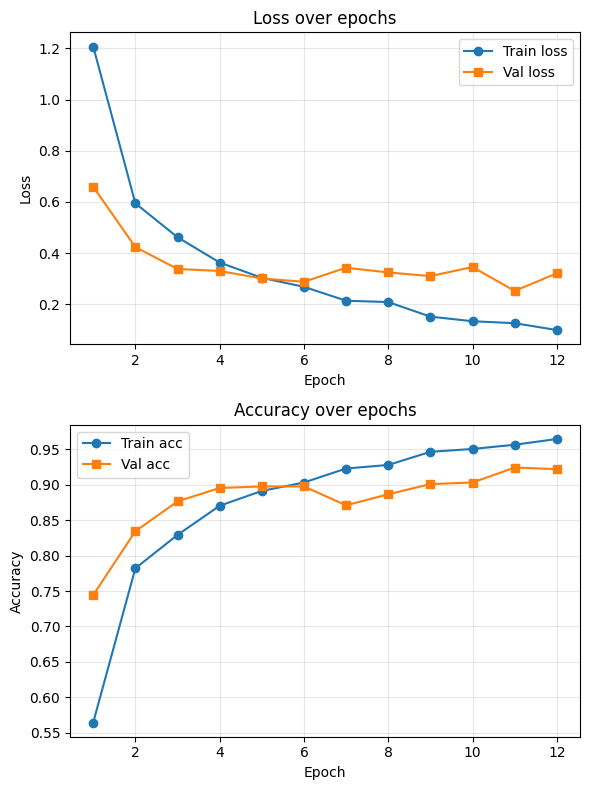

Saved vertically-stacked learning curves.


In [54]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

# 2 rows, 1 column = vertically stacked. Taller than wide, fits a single IEEE column.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# --- Top: Loss ---
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train loss')
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Bottom: Accuracy ---
ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train acc')
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{save_dir}/figures/learning_curves.png', dpi=300, bbox_inches='tight')  # save BEFORE show
plt.show()

print("Saved vertically-stacked learning curves.")